# Implementation of the Article: A Genetic Algorithm for Portfolio Optimization Based on Market Dynamics and Asset Valuations

This section covers the step-by-step implementation of the portfolio optimization method proposed in the paper *A Genetic Algorithm (GA) Approach to the Portfolio Design Based on Market Movements and Asset Valuations*. The approach uses GA to select undervalued stocks while maximizing risk-adjusted returns. 


*By Amro Benramdane and Martin Hamelle, M1 Miage Group 1*


We will follow this flow chart step by step :)

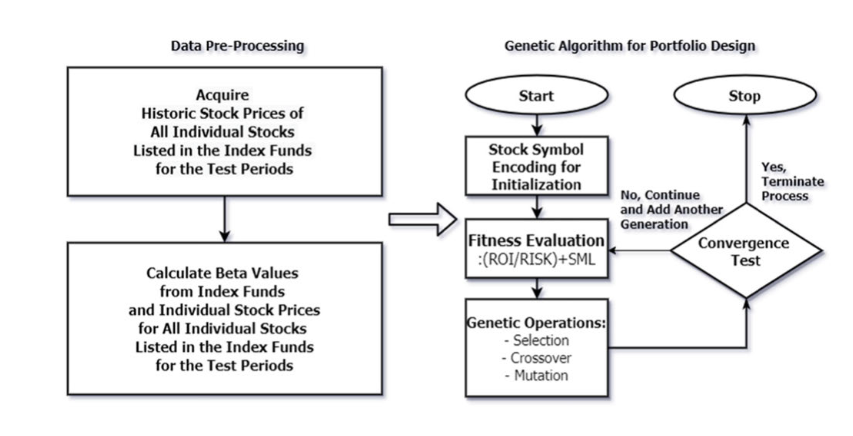

#### Libraries needed

In [1]:
!pip install --upgrade statsmodels
!pip install --upgrade numexpr bottleneck

DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
DEPRECATION: pyodbc 4.0.0-unsupported has a non-standard version number. pip 24.1 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of pyodbc or contact the author to suggest that they release a version with a conforming version number. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import pandas as pd
import datetime
import os
from typing import List, Dict

## 1. Data Pre-Processing

In [3]:
def load_sp500_adjclose(folder_path, start_date=None, end_date=None):
    """
    Extracts close adjusted prices of each stock on the S&P500 and returns a dict with all of them
    """
    adjclose_monthly = {}
    
    for filename in os.listdir(folder_path):
        if not filename.lower().endswith('.csv'):
            continue
        
        ticker = os.path.splitext(filename)[0]
        file_path = os.path.join(folder_path, filename)
        
        try:
            df = pd.read_csv(file_path, index_col=0, parse_dates=True)
        except Exception:
            continue
        if 'Adj Close' not in df.columns:
            continue
        series_adj = df['Adj Close'].copy()
        
        if start_date is not None:
            series_adj = series_adj[series_adj.index >= pd.to_datetime(start_date)]
        if end_date is not None:
            series_adj = series_adj[series_adj.index <= pd.to_datetime(end_date)]
            
        series_monthly = series_adj.resample('ME')
        series_monthly.name = ticker
        adjclose_monthly[ticker] = series_monthly
        
    return adjclose_monthly


In [4]:
def load_sp500_index_monthly(csv_path, start_date="2008-01-01", end_date="2020-12-31"):
    """
       returns s&p500 index price each start of the month
    """
    
    index_df = pd.read_csv(
        csv_path,
        usecols=["Date", "Price"], 
        dtype={"Date": "string", "Price": "string"},
    )

    
    index_df["Date"] = pd.to_datetime(index_df["Date"], format="%m/%d/%Y")
    index_df.set_index("Date", inplace=True)
    index_df.sort_index(inplace=True)

    
    index_df["Price"] = (
        index_df["Price"]
        .str.replace(",", "", regex=False)
        .astype(float)
    )

    index_df = index_df.loc[start_date : end_date]
 
    index_monthly = index_df.resample("MS").first()

    index_month_start_dates = index_monthly.index.to_list()
    index_start_prices       = index_monthly["Price"].to_list()

    return index_month_start_dates, index_start_prices


In [17]:

def calculate_3year_monthly_beta(stock_prices, market_prices):
    """
    Calculates monthly beta values using an OLS regression over a rolling 3-year (36-month) window.
    
    Parameters:
    - stock_prices : pd.Series, monthly prices of the individual stock (indexed by date)
    - market_prices : pd.Series, monthly prices of the market index (indexed by date)

    Returns:
    - pd.Series of monthly beta values (one beta per end-of-window month)
    """
    beta_values = []
    index_values = []

    data = pd.DataFrame({'stock': stock_prices, 'market': market_prices}).dropna()
    
    if len(data) < 36:
    # Pas assez de données pour calculer un seul bêta
        return pd.Series(dtype=float)

    for i in range(36, len(data)):
        window_data = data.iloc[i-36:i].copy()

        
        window_data['stock_return'] = window_data['stock'].pct_change()
        window_data['market_return'] = window_data['market'].pct_change()

        
        window_data = window_data.dropna()

        
        X = sm.add_constant(window_data['market_return'])  
        y = window_data['stock_return']
        model = sm.OLS(y, X).fit()

        beta = model.params['market_return']
        beta_values.append(beta)
        index_values.append(data.index[i])  

    return pd.Series(beta_values, index=index_values, name="Beta")


###  1. Acquire historic stock prices

#### We chose to test our implementation with the *'S&P500'* stocks data

##### All individual stock prices (adjusted) 

In [7]:
folder_path = '/Users/amrobenramdane/Documents/M1Info/Implementation_GAforPM/sp500yf'


start_date = '2008-01-01'
end_date   = '2020-12-31'


#monthly prices of all stocks in the S&P500
sp500_stock_dict = load_sp500_adjclose(folder_path, start_date=start_date, end_date=end_date)

print(f"Number de stocks in total :{len(list(sp500_stock_dict.keys()))}")
#print("Stocks found (adjusted close prices) :", list(sp500_stock_dict.keys()))


# We take only values of the start of each month
master_month_starts = pd.date_range(start=start_date, end=end_date, freq="MS")


sp500_stock_prices = {}

for ticker, monthly_data in sp500_stock_dict.items():
    temp = {}
    for (_, daily_series) in monthly_data:
        first_trade = daily_series.index.min()
        price       = daily_series.iloc[0]
        month_start = pd.Timestamp(first_trade.year, first_trade.month, 1)
        temp[month_start] = price

    ts            = pd.Series(temp)
    ts_master     = ts.reindex(master_month_starts)
    ts_master.name = ticker

    sp500_stock_prices[ticker] = ts_master


print(len(sp500_stock_prices['ABC']))
print(len(master_month_starts))

Number de stocks in total :505
156
156


In [8]:
print(sp500_stock_prices['ABC'][:3])
print(list(sp500_stock_dict['ABC'])[:3])#we verify each start of the month(it has to be equal to the first print)

2008-01-01    18.452917
2008-02-01    19.314459
2008-03-01    17.210073
Freq: MS, Name: ABC, dtype: float64
[(Timestamp('2008-01-31 00:00:00'), Date
2008-01-02    18.452917
2008-01-03    18.564751
2008-01-04    18.142260
2008-01-07    18.382488
2008-01-08    18.908541
2008-01-09    19.078367
2008-01-10    19.347601
2008-01-11    19.596127
2008-01-14    19.562986
2008-01-15    18.999662
2008-01-16    19.447008
2008-01-17    19.318609
2008-01-18    19.297895
2008-01-22    19.078367
2008-01-23    18.954102
2008-01-24    19.024517
2008-01-25    18.626879
2008-01-28    18.763565
2008-01-29    19.765951
2008-01-30    19.500856
2008-01-31    19.293753
Name: Adj Close, dtype: float64), (Timestamp('2008-02-29 00:00:00'), Date
2008-02-01    19.314459
2008-02-04    19.587841
2008-02-05    19.132212
2008-02-06    18.958246
2008-02-07    18.829844
2008-02-08    18.775990
2008-02-11    18.374214
2008-02-12    18.581314
2008-02-13    18.396692
2008-02-14    18.118704
2008-02-15    18.097960
2008-02-1

##### S&P500 index prices

In [10]:
csv_path = "S&P-500-Historical-Data.csv"
dates, sp500_index_prices = load_sp500_index_monthly(csv_path)
dates = master_month_starts
#----here we will use sp500_index_prices-----


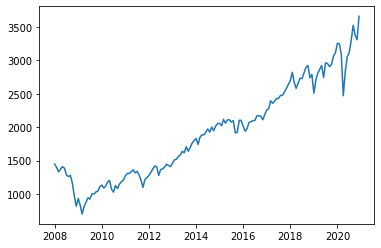

In [12]:
plt.plot(dates,sp500_index_prices)

#### Conclusion for the data processing part :

So now we have *dates* a list with the start of each month from 2008 to 2020. We have *sp500_stock_prices* a dictionnary with all the prices each moth for all S&P500 stocks and *sp500_index_prices* with all the prices of the index each start of the month.

###  2. Compute the Beta for each stock

In [18]:
Beta_dict = {}

for stock in sp500_stock_prices.keys():
    Beta_dict[stock] = calculate_3year_monthly_beta(sp500_stock_prices[stock],sp500_index_prices)

Beta_dict['NLSN']

2014-01-01    0.793776
2014-02-01    0.802864
2014-03-01    0.868527
2014-04-01    0.930421
2014-05-01    0.909210
                ...   
2020-08-01    1.278140
2020-09-01    1.252550
2020-10-01    1.238322
2020-11-01    1.232598
2020-12-01    1.220982
Name: Beta, Length: 84, dtype: float64

#### We have now all the data to start the Genetic algorithm

## 2. Genetic Algorithm

In [22]:
def encode_stocks(stocks: List[str]) -> Dict[str, int]:
    """
    Assign each stock to a unique bit-position in the binary chromosome.
    """
    return {stocks[i]: i for i in range(len(stocks))}

In [23]:
def initialize_population(stocks: List[str], pop_size: int) -> np.ndarray:
    """
    Generate a random population of binary chromosomes (pop_size × N), where N = len(stocks).
    A bit of 1 means that stock is included. Ensures no chromosome is entirely zero.
    """
    N = len(stocks)
    population = np.random.randint(0, 2, size=(pop_size, N), dtype=int)
    for i in range(pop_size):
        if not population[i].any():
            j = np.random.randint(0, N)
            population[i, j] = 1
    return population

In [26]:
import numpy as np
import pandas as pd

def compute_capm_series(beta_dict, month, market_return, risk_free_rate):
    """
    Given a dictionary of beta Series for all stocks, extracts each stock’s beta
    at the specified month and computes its CAPM value.

    Parameters:
    - beta_dict     : dict[str → pd.Series], where each pd.Series is indexed by timestamp
                      and contains the 3-year rolling beta for that stock.
    - month         : pd.Timestamp or string “YYYY-MM-DD” indicating the month-end date
                      at which to read each stock’s beta (e.g. “2008-01-31”).
    - market_return : float, the realized return of the market index over that month
                      (e.g. (S&P_close_end – S&P_close_start) / S&P_close_start).
    - risk_free_rate: float, the risk-free rate for that same month (in decimal form).

    Returns:
    - capm_series : pd.Series indexed by stock symbol, where
                    CAPM_i = β_i(month) * (market_return – risk_free_rate).
                    If a stock’s beta is missing at “month”, its CAPM is set to 0.0.
    """
    # Ensure month is a Timestamp
    month_ts = pd.to_datetime(month)

    capm_values = {}
    for stock, beta_ser in beta_dict.items():
        # Try to get beta at exactly month_ts; if missing, use .asof()
        try:
            beta_i = beta_ser.loc[month_ts]
        except KeyError:
            # If month not in index, take the last valid index <= month_ts
            beta_i = beta_ser.asof(month_ts)

        if pd.isna(beta_i):
            capm_values[stock] = 0.0
        else:
            capm_values[stock] = float(beta_i) * (market_return - risk_free_rate)

    return pd.Series(capm_values, name="CAPM")


def calculate_portfolio_fitness(chromosome,
                                price_df,
                                beta_dict,
                                month,
                                market_return,
                                start_date,
                                end_date,
                                initial_funds,
                                fee_rate,
                                tax_rate,
                                risk_free_rate):
    """
    Calculates the fitness of a single chromosome (portfolio) using Table 4’s logic,
    but now computing CAPM from beta_dict at the requested month.

    Parameters:
    - chromosome     : pd.Series or 1D array of 0/1 (indexed by stock symbol).
                       “1” = include the stock, “0” = exclude.
    - price_df       : pd.DataFrame of daily adjusted-close prices for all stocks.
                       Index = date (Timestamp), columns = stock symbols.
                       Must cover at least [start_date, end_date].
    - beta_dict      : dict[str → pd.Series], each Series = 3-year rolling beta indexed by date.
    - month          : pd.Timestamp or string “YYYY-MM-DD” for which to pull each stock’s beta.
    - market_return  : float, the market’s monthly return for that same “month.”
    - start_date     : string “YYYY-MM-DD” or pd.Timestamp for purchase date.
    - end_date       : string “YYYY-MM-DD” or pd.Timestamp for sale date.
    - initial_funds  : float, total budget to allocate across selected stocks.
    - fee_rate       : float, handling (transaction) fee rate (e.g. 0.001 for 0.1%).
    - tax_rate       : float, tax rate on sale proceeds (e.g. 0.001 for 0.1%).
    - risk_free_rate : float, the risk-free rate over that month (decimal, e.g. 0.002).

    Returns:
    - float : the computed fitness for this chromosome.
    """
    # 1) Convert chromosome to pd.Series if it’s a numpy array
    if isinstance(chromosome, np.ndarray):
        symbols = price_df.columns
        chromosome = pd.Series(chromosome, index=symbols).astype(int)
    else:
        chromosome = chromosome.astype(int)
        symbols = list(chromosome.index)

    selected = chromosome[chromosome == 1].index.tolist()
    m = len(selected)

    # 2) Si aucun stock sélectionné → fitness = 0
    if m == 0:
        return 0.0

    # 3) Allouer initial_funds / m par stock
    allocated_per_stock = initial_funds / m

    # 4) Obtenir les prix “start” et “end” pour chaque stock sélectionné
    #    On utilise .ffill().iloc[-1] pour s’assurer d’avoir le prix le plus proche ≤ date.
    prices_start = (
        price_df.loc[:pd.to_datetime(start_date), selected]
        .ffill()
        .iloc[-1]
    )
    prices_end = (
        price_df.loc[:pd.to_datetime(end_date), selected]
        .ffill()
        .iloc[-1]
    )

    # 5) Calculer la série CAPM dérivée de beta_dict pour “month”
    capm_series = compute_capm_series(beta_dict, month, market_return, risk_free_rate)

    fund_std_list = []
    capm_list = []
    remaining_budget_total = 0.0

    for stock in selected:
        price_buy = float(prices_start[stock])
        price_sell = float(prices_end[stock])

        # 5.a) Nombre d’actions entières qu’on peut acheter
        shares = np.floor(allocated_per_stock / price_buy)

        # 5.b) Frais de transaction à l’achat
        handling_fee = shares * price_buy * fee_rate

        # 5.c) Montant dépensé pour l’achat
        cost_purchase = shares * price_buy + handling_fee

        # 5.d) Budget restant sur cette portion
        remaining_budget = allocated_per_stock - cost_purchase

        # 5.e) Produit de la vente à end_date
        sales_proceeds = shares * price_sell

        # 5.f) Taxe sur la vente
        tax_amount = shares * price_sell * tax_rate

        # 5.g) fund_standardization_i
        fund_std = sales_proceeds - handling_fee - tax_amount + remaining_budget
        fund_std_list.append(fund_std)

        # 5.h) fund_CAPM_i = capm_series[stock]
        capm_i = float(capm_series.get(stock, 0.0))
        capm_list.append(capm_i)

        remaining_budget_total += remaining_budget

    # 6) Portfolio fund standardization = Σ fund_std_list
    portfolio_fund_standardization = np.sum(fund_std_list)

    # 7) Portfolio CAPM = Σ capm_list
    portfolio_capm = np.sum(capm_list)

    # 8) ROI en %
    roi = (portfolio_fund_standardization - initial_funds) / initial_funds * 100

    # 9) Risk = écart‐type(fund_std_list) / moyenne(fund_std_list)
    mean_fund_std = np.mean(fund_std_list)
    std_fund_std = np.std(fund_std_list, ddof=0)
    if np.isclose(mean_fund_std, 0.0):
        risk = 1e-9
    else:
        risk = std_fund_std / mean_fund_std

    # 10) Fitness = (ROI – risk_free_rate) / risk + portfolio_capm
    fitness_value = (roi - risk_free_rate) / risk + portfolio_capm

    return float(fitness_value)


In [27]:
from typing import List, Union

Chromosome = Union[np.ndarray, "pd.Series"]  # either a NumPy array or pd.Series of 0/1 integers
Population = List[Chromosome]
FitnessList = List[float]

def tournament_selection(
    population: Population,
    fitnesses: FitnessList
) -> Population:
    """
    Perform “binary tournament” selection to produce a new population of the same size.
    For each position i in the (offspring) population:
      - pick a random index j between [0, pop_size-1]
      - compare fitness[i] vs. fitness[j]
      - copy the chromosome with higher fitness into the new population at position i

    Parameters:
    - population: list of chromosomes (each chromosome is a 0/1 array or Series)
    - fitnesses : list (or 1D array) of floats, same length as population

    Returns:
    - new_population: a list of chromosomes (same length as `population`), selected by tournament
    """
    pop_size = len(population)
    new_pop: Population = []
    
    for i in range(pop_size):
        # pick a random “opponent” index
        j = random.randrange(pop_size)
        # compare fitnesses; higher‐fitness “wins”
        if fitnesses[i] >= fitnesses[j]:
            winner = population[i]
        else:
            winner = population[j]
        # append a *copy* of the winner (so we don’t accidentally modify the original)
        new_pop.append(winner.copy())
    
    return new_pop


def one_point_crossover(
    population: Population,
    crossover_rate: float = 1.0
) -> Population:
    """
    Perform one-point crossover on the population.  
    We assume `population` size is even. For each consecutive pair of parents:
      - with probability = crossover_rate, choose a random crossover point k in [1..L-1], where 
        L = chromosome length.  
      - swap all bits from k onward between the two parents to form two offspring.  
      - with probability (1 – crossover_rate), the two parents are copied unchanged.

    Parameters:
    - population     : list of chromosomes (each chromosome is a 0/1 array or Series)
    - crossover_rate : float between 0 and 1. If a random number < crossover_rate, we do crossover;
                       otherwise, we copy parents as‐is.

    Returns:
    - new_population : list of chromosomes after crossover (same length as `population`)
    """
    pop_size = len(population)
    assert pop_size % 2 == 0, "Population size must be even for pairwise crossover."
    
    new_pop: Population = []
    for idx in range(0, pop_size, 2):
        parent1 = population[idx]
        parent2 = population[idx+1]
        
        # Convert to NumPy array if it is a pandas Series
        p1 = parent1.values if hasattr(parent1, "values") else parent1
        p2 = parent2.values if hasattr(parent2, "values") else parent2
        
        L = len(p1)
        # If L < 2, no valid interior crossover point; just copy both parents
        if L < 2:
            new_pop.append(p1.copy())
            new_pop.append(p2.copy())
            continue
        
        # Decide whether to actually crossover
        if random.random() < crossover_rate:
            # choose a point between 1 and L-1 (so we actually swap something)
            k = random.randrange(1, L)
            offspring1 = np.concatenate([p1[:k], p2[k:]])
            offspring2 = np.concatenate([p2[:k], p1[k:]])
        else:
            offspring1 = p1.copy()
            offspring2 = p2.copy()
        
        new_pop.append(offspring1)
        new_pop.append(offspring2)
    
    # If the original chromosomes were pandas Series, convert back (same index, same name)
    for i in range(pop_size):
        if hasattr(population[i], "index"):
            new_pop[i] = type(population[i])(data=new_pop[i], index=population[i].index, name=population[i].name)
    
    return new_pop


def mutation(
    population: Population,
    mutation_rate: float
) -> Population:
    """
    Perform bit-flip mutation on each chromosome in the population.  
    For every gene (position) in every chromosome, we generate a random number r in [0,1).  
    If r < mutation_rate, we flip that bit (0→1 or 1→0).

    Parameters:
    - population    : list of chromosomes (each chromosome is a 0/1 array or Series)
    - mutation_rate : float between 0 and 1; probability of flipping each bit

    Returns:
    - new_population: list of chromosomes after mutation (same length & shape as `population`)
    """
    new_pop: Population = []
    for chrom in population:
        # Convert to NumPy array if needed
        if hasattr(chrom, "values"):
            arr = chrom.values.copy()
            is_series = True
            idx = chrom.index
            nm = chrom.name
        else:
            arr = chrom.copy()
            is_series = False
        
        # bit-flip each gene with probability = mutation_rate
        for g in range(len(arr)):
            if random.random() < mutation_rate:
                arr[g] = 1 - arr[g]  # flip 0→1 or 1→0
        
        # convert back to pandas Series if needed
        if is_series:
            new_chrom = type(chrom)(data=arr, index=idx, name=nm)
        else:
            new_chrom = arr
        new_pop.append(new_chrom)
    
    return new_pop
